## 1. Persiapan Lingkungan Kerja dan Dataset
Tahapan ini bertujuan untuk menghubungkan Google Colab dengan Google Drive, mengunduh repositori proyek dari GitHub, mengekstrak dataset `Alzheimer_Split`, dan menginstal seluruh dependensi pustaka yang dibutuhkan.

In [1]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 2. Pindah ke root directory Colab
%cd /content

/content


In [3]:
# 3. Bersihkan sisa folder lama (jaga-jaga kalau masih ada)
!rm -rf Tugas-Besar_Machine-Learning_PS1SD-05-REG01

In [4]:
# 4. Clone fresh dari GitHub Projek kelompok
!git clone https://github.com/naocheda/Tugas-Besar_Machine-Learning_PS1SD-05-REG01.git
%cd Tugas-Besar_Machine-Learning_PS1SD-05-REG01

Cloning into 'Tugas-Besar_Machine-Learning_PS1SD-05-REG01'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 96 (delta 33), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 94.58 KiB | 2.56 MiB/s, done.
Resolving deltas: 100% (33/33), done.
/content/Tugas-Besar_Machine-Learning_PS1SD-05-REG01


In [5]:
# 5. Ekstrak dataset (pakai -q biar outputnya ga membanjiri layar)
!unzip -q -o "/content/drive/MyDrive/Projek tubes ml/Alzheimer_Split.zip" -d .

In [6]:
# 6. Install library sesuai requirements
!pip install -r requirements.txt

## 2. Eksperimen Transfer Learning (MobileNetV2)
Bagian ini mengeksekusi proses pelatihan dan evaluasi menggunakan arsitektur **MobileNetV2** (berbasis *pre-trained weights*). Model ini digunakan sebagai solusi utama untuk mengatasi kompleksitas ekstraksi fitur pada citra MRI.

In [ ]:
# 7. SIKAT TRAININGNYA!
!python train.py

### 2.1. Evaluasi Performa MobileNetV2
Memuat kembali bobot model terbaik dari Google Drive untuk mencegah *training* ulang, dilanjutkan dengan pengujian model menggunakan data *testing* untuk melihat metrik *Classification Report*.

In [7]:
!cp "/content/drive/MyDrive/Projek tubes ml/mobilenet_v2_model.pth" .

In [8]:
!python evaluation.py

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
100% 13.6M/13.6M [00:00<00:00, 63.1MB/s]

Classification Report:
                    precision    recall  f1-score   support

      Non_Demented       0.95      0.92      0.93       480
Very_Mild_Demented       0.87      0.93      0.90       336
     Mild_Demented       0.92      0.88      0.90       135

          accuracy                           0.91       951
         macro avg       0.91      0.91      0.91       951
      weighted avg       0.92      0.91      0.92       951

Overall Accuracy: 91.48%


## 3. Eksperimen Baseline (CNN Dasar)
Sebagai studi komparatif, bagian ini melatih arsitektur **CNN Dasar** konvensional (2 lapis konvolusi) yang digunakan sebagai acuan awal. Pelatihan dilakukan selama 40 *epoch* untuk melihat batasan performa model sederhana pada dataset medis ini tanpa menggunakan bobot tambahan (*pre-trained weights*).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from data_loader import get_dataloaders
from models import get_baseline_cnn

# Pemanasan GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, test_loader = get_dataloaders('Alzheimer_Dataset_Details.csv', 'Alzheimer_Split')

# MANGGIL CNN BUATAN SENDIRI (Bukan Transfer Learning)
model = get_baseline_cnn(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

print("Memulai Training Baseline CNN...")
for epoch in range(40):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

# Disimpan dengan nama beda biar aman
torch.save(model.state_dict(), 'baseline_cnn_model.pth')
print("Training beres! File disave jadi 'baseline_cnn_model.pth'")

### 3.1. Evaluasi Performa CNN Dasar
Memuat bobot model CNN Dasar (*40 epoch*) dari penyimpanan lokal/Drive, kemudian mengevaluasi kemampuannya dalam mengklasifikasikan data uji yang belum pernah dilihat sebelumnya (*unseen data*).

In [9]:
!cp "/content/drive/MyDrive/Projek tubes ml/baseline_cnn_model (40 epoch).pth" .

In [11]:
import torch
from sklearn.metrics import classification_report, accuracy_score
from data_loader import get_dataloaders
from models import get_baseline_cnn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_, test_loader = get_dataloaders('Alzheimer_Dataset_Details.csv', 'Alzheimer_Split')

# Load CNN Dasar
model_cnn = get_baseline_cnn(num_classes=3).to(device)
model_cnn.load_state_dict(torch.load('baseline_cnn_model (40 epoch).pth'))
model_cnn.eval()

y_true_cnn = []
y_pred_cnn = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_cnn(images)
        _, predicted = torch.max(outputs.data, 1)

        y_true_cnn.extend(labels.cpu().numpy())
        y_pred_cnn.extend(predicted.cpu().numpy())

print("\n--- HASIL EVALUASI CNN DASAR ---")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=['Non_Demented', 'Very_Mild_Demented', 'Mild_Demented']))
print(f"Overall Accuracy: {accuracy_score(y_true_cnn, y_pred_cnn)*100:.2f}%")


--- HASIL EVALUASI CNN DASAR ---
                    precision    recall  f1-score   support

      Non_Demented       0.89      0.76      0.82       480
Very_Mild_Demented       0.67      0.85      0.75       336
     Mild_Demented       0.77      0.64      0.70       135

          accuracy                           0.78       951
         macro avg       0.78      0.75      0.76       951
      weighted avg       0.80      0.78      0.78       951

Overall Accuracy: 77.71%


## 4. Visualisasi Komparasi Hasil
Pembuatan visualisasi *Grouped Bar Chart* untuk membandingkan secara detail metrik akurasi keseluruhan dan F1-Score tiap kelas antara model **CNN Dasar** dengan **MobileNetV2**.

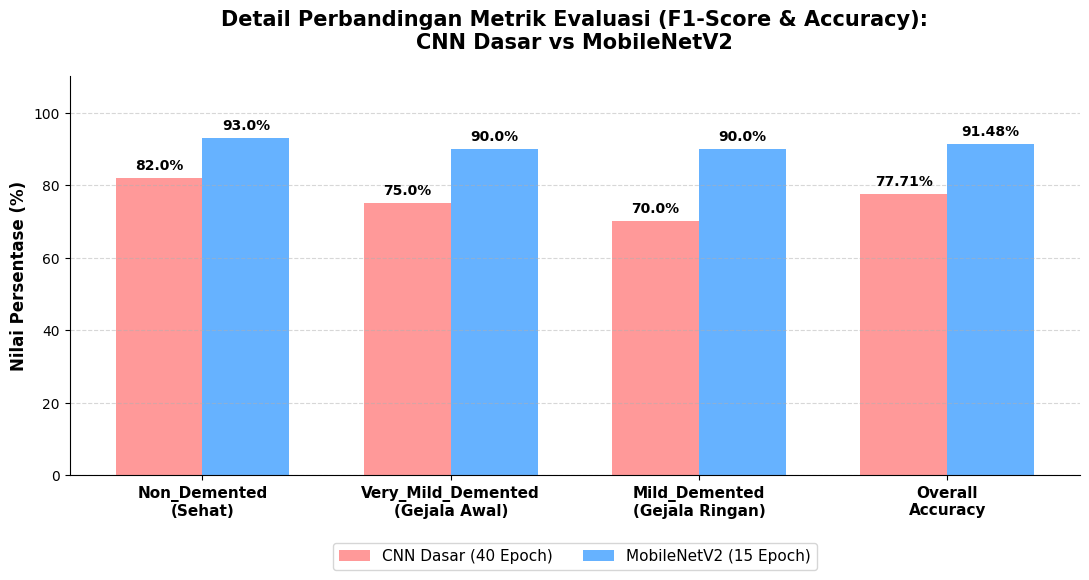

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. KATEGORI YANG MAU DIBANDINGIN
labels = ['Non_Demented\n(Sehat)', 'Very_Mild_Demented\n(Gejala Awal)', 'Mild_Demented\n(Gejala Ringan)', 'Overall\nAccuracy']

# 2. HASIL MOBILENETV2 (Dari screenshot 91.48%)
mobilenet_scores = [93.0, 90.0, 90.0, 91.48]

# 3. HASIL CNN DASAR (Dari screenshot 77.71%)
cnn_scores = [82.0, 75.0, 70.0, 77.71]

x = np.arange(len(labels))
width = 0.35

# Bikin kanvas grafiknya
fig, ax = plt.subplots(figsize=(11, 6))

# Gambar batangnya
rects1 = ax.bar(x - width/2, cnn_scores, width, label='CNN Dasar (40 Epoch)', color='#ff9999')
rects2 = ax.bar(x + width/2, mobilenet_scores, width, label='MobileNetV2 (15 Epoch)', color='#66b2ff')

# Dandanin Teks, Judul, dan Sumbu
ax.set_ylabel('Nilai Persentase (%)', fontsize=12, fontweight='bold')
ax.set_title('Detail Perbandingan Metrik Evaluasi (F1-Score & Accuracy):\nCNN Dasar vs MobileNetV2', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True, fontsize=11)
ax.set_ylim(0, 110)

# Fungsi otomatis buat nulis angka di pucuk tiap batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

autolabel(rects1)
autolabel(rects2)

# Desain bingkai
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Render dan simpan gambar
plt.tight_layout()
plt.savefig('grafik_komparasi_detail.png', dpi=300)
plt.show()